## Set Up

In [1]:
import os
os.environ["R_HOME"] = "/Library/Frameworks/R.framework/Resources"

In [2]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [3]:
%%R
reg_df <- read.csv("reg_df.csv")
model <- lm(
    OBESITY_CrudePrev ~ pct_female + pct_white + pct_black + pct_asian
                      + pct_hispanic + pct_poverty + med_inc_10k,
    data = reg_df
)
summary(model)


Call:
lm(formula = OBESITY_CrudePrev ~ pct_female + pct_white + pct_black + 
    pct_asian + pct_hispanic + pct_poverty + med_inc_10k, data = reg_df)

Residuals:
     Min       1Q   Median       3Q      Max 
-16.2463  -2.6288   0.2328   2.9368  17.4430 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   43.99636    1.63701  26.876  < 2e-16 ***
pct_female   -12.13171    1.39487  -8.697  < 2e-16 ***
pct_white     -2.01657    1.49537  -1.349    0.178    
pct_black      0.22324    1.56778   0.142    0.887    
pct_asian    -27.67517    1.61814 -17.103  < 2e-16 ***
pct_hispanic  -6.07545    1.50257  -4.043 5.35e-05 ***
pct_poverty   12.67428    0.75131  16.870  < 2e-16 ***
med_inc_10k   -0.67706    0.02055 -32.954  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.573 on 5189 degrees of freedom
Multiple R-squared:  0.5733,	Adjusted R-squared:  0.5728 
F-statistic: 996.1 on 7 and 5189 DF,  p-value: < 2.

# Residual Analysis

In [4]:
%%R -o reg_df

library(tidyverse)

reg_df <- reg_df |>
    mutate(
        pred = predict(model),
        resid = resid(model)
    )

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [6]:
reg_df.sort_values(by='resid')

,GEOID,county,population_estimate,med_inc_estimate,pct_female,pct_white,pct_black,pct_asian,pct_hispanic,pct_poverty,TractFIPS,CountyName,OBESITY_CrudePrev,med_inc_10k,pred,resid
963,3.606101e+10,New York County,214.0,83857.0,0.383178,0.813084,0.037383,0.032710,0.037383,0.121495,3.606101e+10,New York,16.2,8.3857,32.446286,-16.246286
64,3.608116e+10,Queens County,2075.0,60800.0,0.660241,0.962892,0.000000,0.034699,0.002410,0.125783,3.608116e+10,Queens,15.2,6.0800,30.547487,-15.347487
2428,3.605502e+10,Monroe County,2621.0,16167.0,0.558565,0.706219,0.105685,0.061427,0.089660,0.617834,3.605502e+10,Monroe,25.0,1.6167,40.310718,-15.310718
678,3.606102e+10,New York County,4036.0,58835.0,0.545590,0.449703,0.095144,0.249009,0.161546,0.266542,3.606102e+10,New York,12.9,5.8835,28.013698,-15.113698
2945,3.610900e+10,Tompkins County,3424.0,31165.0,0.427862,0.610105,0.025701,0.181951,0.013143,0.283586,3.610900e+10,Tompkins,19.0,3.1165,33.949885,-14.949885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,3.606302e+10,Niagara County,2608.0,19660.0,0.595475,0.124233,0.683666,0.019555,0.082822,0.581672,3.606302e+10,Niagara,57.6,1.9660,41.671103,15.928897
2592,3.606700e+10,Onondaga County,1554.0,40200.0,0.476834,0.309524,0.160875,0.364221,0.084942,0.256757,3.606700e+10,Onondaga,44.0,4.0200,27.559740,16.440260
4731,3.606701e+10,Onondaga County,1835.0,48893.0,0.534060,0.227793,0.504632,0.000000,0.045232,0.184422,3.606701e+10,Onondaga,52.9,4.8893,35.922827,16.977173
1655,3.606701e+10,Onondaga County,2055.0,37109.0,0.504623,0.082238,0.757178,0.000000,0.129927,0.250608,3.606701e+10,Onondaga,55.1,3.7109,37.752008,17.347992


In [ ]:
%%R -o ny_df
ny_df <- reg_df |> filter(CountyName == "New York")

In [ ]:
ny_df

# NYC Map

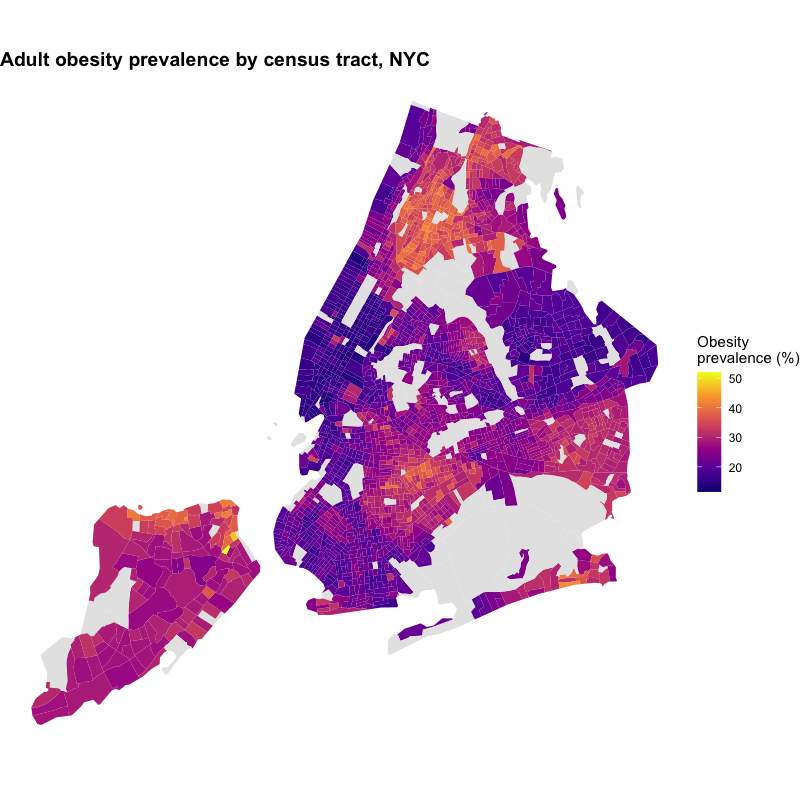

In [24]:
%%R -w 800 -h 800 -r 100
# install once if needed:
# install.packages(c("sf", "tigris"))

library(sf)
library(tigris)
options(tigris_use_cache = TRUE)

nyc_fips <- c("005", "047", "061", "081", "085")  # Bronx, Kings, NY, Queens, Richmond

tracts <- do.call(rbind, lapply(nyc_fips, function(co)
    tracts(state = "36", county = co, year = 2020, cb = TRUE, progress_bar = FALSE)
))

map_df <- reg_df |>
    mutate(GEOID = sprintf("%011.0f", as.numeric(GEOID))) |>
    select(GEOID, OBESITY_CrudePrev, pred, resid)

nyc_map <- tracts |>
    select(GEOID) |>
    left_join(map_df, by = "GEOID") |>
    st_transform(2263)

ggplot(nyc_map) +
    geom_sf(aes(fill = OBESITY_CrudePrev), color = NA) +
    scale_fill_viridis_c(option = "plasma", name = "Obesity\nprevalence (%)",
                         na.value = "grey90") +
    labs(title = "Adult obesity prevalence by census tract, NYC") +
    theme_void() +
    theme(plot.title = element_text(face = "bold", size = 14))


## Predicted values

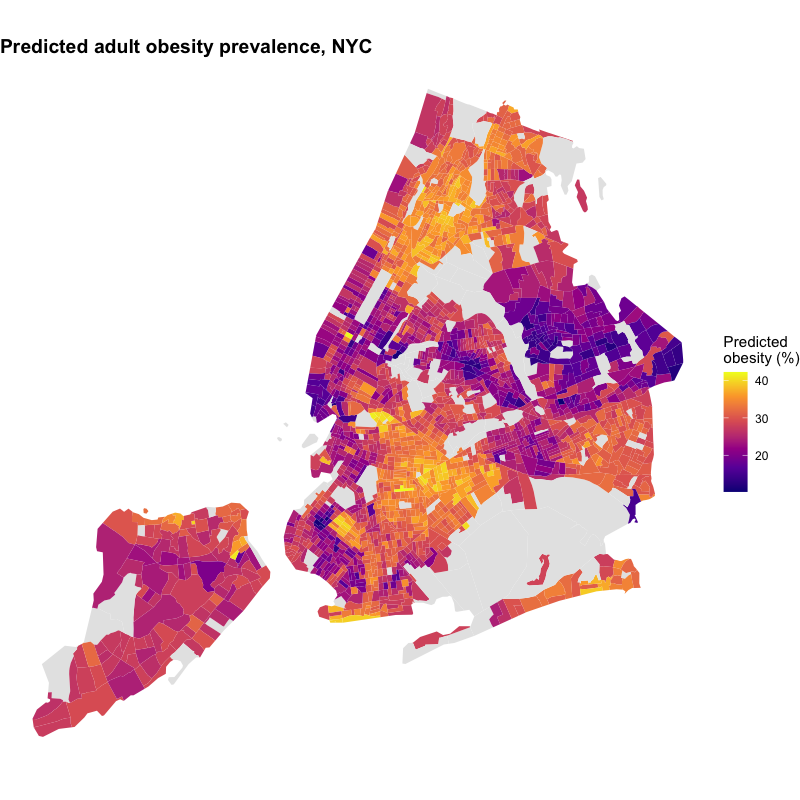

In [25]:
%%R -w 800 -h 800 -r 100
ggplot(nyc_map) +
    geom_sf(aes(fill = pred), color = NA) +
    scale_fill_viridis_c(option = "plasma", name = "Predicted\nobesity (%)",
                         na.value = "grey90") +
    labs(title = "Predicted adult obesity prevalence, NYC") +
    theme_void() +
    theme(plot.title = element_text(face = "bold", size = 14))


## Residuals

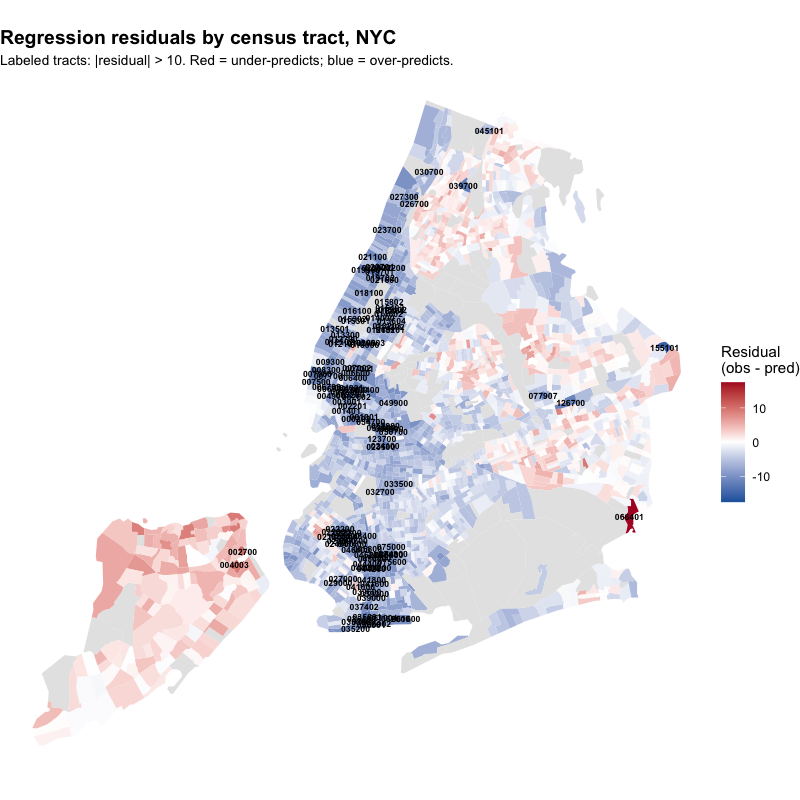

In [29]:
%%R -w 800 -h 800 -r 100
resid_lim <- max(abs(nyc_map$resid), na.rm = TRUE)

# label tracts with the largest residuals
label_df <- nyc_map |>
    filter(!is.na(resid), abs(resid) > 10) |>
    mutate(tract = substr(GEOID, 6, 11))

ggplot(nyc_map) +
    geom_sf(aes(fill = resid), color = NA) +
    geom_sf_text(data = label_df, aes(label = tract),
                 size = 2.2, fontface = "bold", color = "black") +
    scale_fill_gradient2(
        low = "#2166ac", mid = "white", high = "#b2182b",
        midpoint = 0, limits = c(-resid_lim, resid_lim),
        name = "Residual\n(obs - pred)",
        na.value = "grey90"
    ) +
    labs(
        title = "Regression residuals by census tract, NYC",
        subtitle = "Labeled tracts: |residual| > 10. Red = under-predicts; blue = over-predicts."
    ) +
    theme_void() +
    theme(
        plot.title = element_text(face = "bold", size = 14),
        plot.subtitle = element_text(size = 10)
    )


## Top residual tracts (lookup)

In [22]:
%%R
# NYC tracts with the largest |residual|, with tract number for lookup
nyc_top <- nyc_map |>
    st_drop_geometry() |>
    filter(!is.na(resid)) |>
    mutate(
        county_fips = substr(GEOID, 3, 5),
        borough = recode(county_fips,
            "005" = "Bronx", "047" = "Brooklyn", "061" = "Manhattan",
            "081" = "Queens", "085" = "Staten Island"
        ),
        tract = substr(GEOID, 6, 11)
    ) |>
    arrange(desc(resid)) |>
    select(GEOID, borough, tract, OBESITY_CrudePrev, pred, resid)

print(head(nyc_top, 10))   # most under-predicted (positive residual, dark red)
print(tail(nyc_top, 10))   # most over-predicted (negative residual, dark blue)


         GEOID       borough  tract OBESITY_CrudePrev     pred     resid
1  36081066401        Queens 066401              32.8 15.35701 17.442993
2  36085004003 Staten Island 004003              52.0 41.17207 10.827930
3  36085002700 Staten Island 002700              47.5 37.21103 10.288973
4  36005003800         Bronx 003800              37.9 28.56792  9.332081
5  36081028802        Queens 028802              36.2 26.88102  9.318978
6  36085004002 Staten Island 004002              27.3 18.06503  9.234965
7  36085000700 Staten Island 000700              41.2 32.09650  9.103501
8  36085001100 Staten Island 001100              41.3 32.35075  8.949250
9  36085013302 Staten Island 013302              38.1 29.27320  8.826804
10 36085031902 Staten Island 031902              40.6 31.91006  8.689937
           GEOID   borough  tract OBESITY_CrudePrev     pred     resid
2186 36061003400 Manhattan 003400              16.4 30.35181 -13.95181
2187 36047023400  Brooklyn 023400              26.0 40.

In [30]:
import pandas as pd
from IPython.display import display 
pd = ny_df.sort_values(by='resid')

In [32]:
reg_df.groupby('CountyName')['OBESITY_CrudePrev'].mean()   

CountyName
Albany         31.228571
Allegany       35.773333
Bronx          33.229794
Broome         34.717857
Cattaraugus    35.826087
                 ...    
Washington     31.442857
Wayne          37.708000
Westchester    26.416525
Wyoming        35.254545
Yates          33.925000
Name: OBESITY_CrudePrev, Length: 62, dtype: float64

In [33]:
reg_df.loc[reg_df['CountyName'] == 'Queens', 'OBESITY_CrudePrev'].mean()  

np.float64(24.197176820208025)

In [34]:
reg_df.loc[reg_df['CountyName'] == 'Queens', 'OBESITY_CrudePrev'].median()

np.float64(23.6)